In [2]:
#importar librerias
pip install Faker

  Using cached faker-40.21.0-py3-none-any.whl.metadata (16 kB)
Using cached faker-40.21.0-py3-none-any.whl (2.0 MB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
#importar librerias
from faker import Faker

In [6]:
#importar librerias
import pandas as pd

In [3]:
#importar librerias
import random

In [11]:
fake = Faker("es_MX")

In [16]:
datos = []

for i in range(100):
    datos.append({
        "id_usuario": i + 1,
        "nombre": fake.name(),
        "correo": fake.email(),
        "edad": random.randint(18, 70), 
        "plataforma": random.choice(["TikTok", "Instagram", "YouTube"]) 
    })

In [22]:
# cargar datos
df = pd.DataFrame(datos)

In [23]:
#Muestra Informacion 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  100 non-null    int64 
 1   nombre      100 non-null    object
 2   correo      100 non-null    object
 3   edad        100 non-null    int64 
 4   plataforma  100 non-null    object
dtypes: int64(2), object(3)
memory usage: 4.0+ KB


In [24]:
#Estadistica Descriptiva
df.describe(include="all")

,id_usuario,nombre,correo,edad,plataforma
count,100.000000,100,100,100.00000,100
unique,NaN,100,100,NaN,3
top,NaN,Jonás Olmos,ibustamante@example.org,NaN,YouTube
freq,NaN,1,1,NaN,34
mean,50.500000,NaN,NaN,45.94000,NaN
std,29.011492,NaN,NaN,15.70165,NaN
min,1.000000,NaN,NaN,19.00000,NaN
25%,25.750000,NaN,NaN,31.00000,NaN
50%,50.500000,NaN,NaN,48.50000,NaN
75%,75.250000,NaN,NaN,60.00000,NaN


In [27]:
#Librerias para Graficar
import seaborn as sns
import matplotlib.pyplot as plt

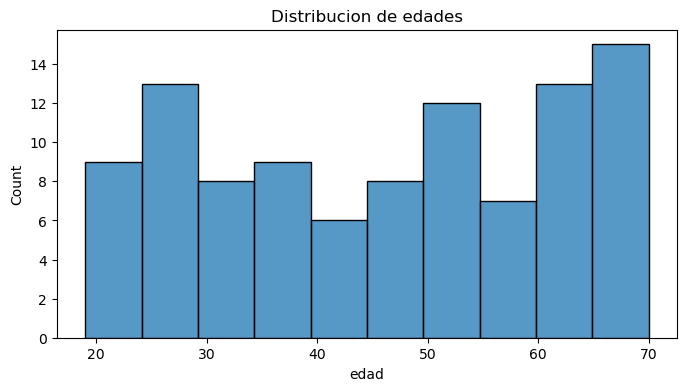

In [28]:
#Distribucion de edades
plt.figure(figsize=(8,4))
sns.histplot(
    df["edad"],
    bins=10
)
plt.title("Distribucion de edades")
plt.show()

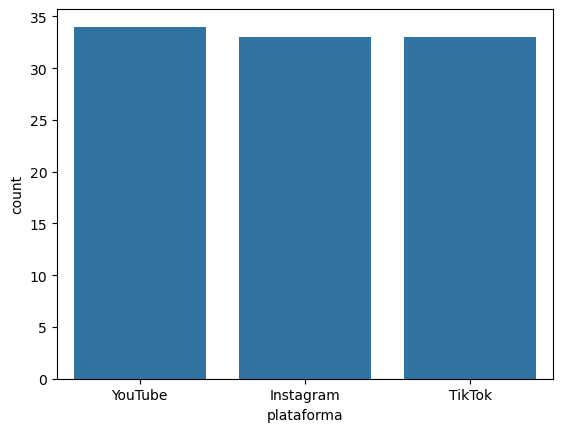

In [29]:
#Usuarios por plataforma
sns.countplot(
    x="plataforma",
    data=df
)
plt.show()

In [30]:
#Generamos una Copia para contaminarla
df_sucio = df.copy()

In [31]:
#Le colocamos valores nulos
for i in random.sample(range(len(df_sucio)), 5):
    df_sucio.loc[i, "nombre"] = None

In [32]:
#Muestra Informacion
df_sucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  100 non-null    int64 
 1   nombre      95 non-null     object
 2   correo      100 non-null    object
 3   edad        100 non-null    int64 
 4   plataforma  100 non-null    object
dtypes: int64(2), object(3)
memory usage: 4.0+ KB


In [33]:
#edades invalidas
for i in random.sample(range(len(df_sucio)), 5):
    df_sucio.loc[i, "edad"] = -10

In [34]:
#Descripcion de edad
df_sucio.describe()["edad"]

count    100.000000
mean      43.340000
std       19.462069
min      -10.000000
25%       29.750000
50%       47.500000
75%       60.000000
max       70.000000
Name: edad, dtype: float64

In [35]:
#Generamos correo invalidos
for i in random.sample(range(len(df_sucio)), 5):
    df_sucio.loc[i, "correo"] = "correo_invalido"

In [38]:
# Opción correcta: Solo usando "object"
df_sucio.describe(include=["object"])

,nombre,correo,plataforma
count,95,100,100
unique,95,96,3
top,Jonás Olmos,correo_invalido,YouTube
freq,1,5,34


In [40]:
df_sucio.isnull().sum()

id_usuario    0
nombre        5
correo        0
edad          0
plataforma    0
dtype: int64

In [41]:
#Estadisticas
df_sucio.describe(include="all")

,id_usuario,nombre,correo,edad,plataforma
count,100.000000,95,100,100.000000,100
unique,NaN,95,96,NaN,3
top,NaN,Jonás Olmos,correo_invalido,NaN,YouTube
freq,NaN,1,5,NaN,34
mean,50.500000,NaN,NaN,43.340000,NaN
std,29.011492,NaN,NaN,19.462069,NaN
min,1.000000,NaN,NaN,-10.000000,NaN
25%,25.750000,NaN,NaN,29.750000,NaN
50%,50.500000,NaN,NaN,47.500000,NaN
75%,75.250000,NaN,NaN,60.000000,NaN


In [7]:
# Creamos un Dataset (original) que servirá como fuente para crear los Datos sintéticos
dfClientes = pd.DataFrame(
    {
        "cliente_id": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        "edad": [23, 33, 43, 28, 53, 56, 43, 56, 65, 40],
        "ingreso_mensual": [25000, 15000, 20000, 10000, 5000, 17000, 30000, 12000, 35000, 7500],
        "ciudad": [
            "Veracruz", 
            "Cordoba", 
            "Paso del macho", 
            "Amatlan", 
            "Fortin", 
            "Cuitlahuac", 
            "Orizaba", 
            "Xalapa", 
            "Boca del Rio", 
            "Coscomatepec"
        ]
    }
)


In [9]:
# Mostramos los 10 registros del dataset original
dfClientes

,cliente_id,edad,ingreso_mensual,ciudad
0,1,23,25000,Veracruz
1,2,33,15000,Cordoba
2,3,43,20000,Paso del macho
3,4,28,10000,Amatlan
4,5,53,5000,Fortin
5,6,56,17000,Cuitlahuac
6,7,43,30000,Orizaba
7,8,56,12000,Xalapa
8,9,65,35000,Boca del Rio
9,10,40,7500,Coscomatepec


In [12]:
#copia de data sucio
df_sucio = dfClientes.copy()

In [13]:
#Mostrar Valores
df_sucio.duplicated().sum()

np.int64(0)

In [ ]:
dfClientesGIGO.describe(include="all")